# MTH9899 DS Project — Intraday Data Analysis

This notebook explores and analyzes intraday market data from the `data_intraday/` folder.

**Data columns:**
- **Date** — Trading date (YYYYMMDD)
- **Time** — Intraday timestamp
- **Id** — Security identifier (Bloomberg-style)
- **CumReturnResid** — Cumulative return residual
- **CumReturnRaw** — Raw cumulative return
- **CumVolume** — Cumulative volume

## 1. Setup and imports

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 5)

# Shared rolling window for per-Id time-series z-scores (target + features)
TS_WINDOW = 252
TS_MIN_PERIODS = 60

# Target only: stabilize TS z when rolling std → 0 and cap extreme z (still per-Id, past-only for mean/var)
TARGET_TSZ_STDFLOOR_REL = 0.12  # sd_eff = max(sd, rel * rolling mean |past returns|)
TARGET_TSZ_CLIP = 6.0           # symmetric cap on Target_norm (after z; no look-ahead)


def zscore_time_series_per_id(
    df,
    col,
    *,
    id_col='Id',
    date_col='Date',
    window=None,
    min_periods=None,
    std_floor_relative=None,
    clip_z=None,
):
    """Rolling z-score per security using only *past* observations (no look-ahead).

    std_floor_relative: if set, denominator is max(rolling std, rel * rolling mean |past x|)
        — reduces blow-ups from near-zero volatility (features: leave None).
    clip_z: if set, clip resulting z to [-clip_z, clip_z] (use for Target_norm only if desired).
    """
    window = TS_WINDOW if window is None else window
    min_periods = TS_MIN_PERIODS if min_periods is None else min_periods
    work = df[[id_col, date_col, col]].copy()
    work['_row'] = np.arange(len(work), dtype=np.int64)
    work = work.sort_values([id_col, date_col], kind='mergesort')

    def _roll_z(s):
        prev = s.shift(1)
        m = prev.rolling(window, min_periods=min_periods).mean()
        sd = prev.rolling(window, min_periods=min_periods).std()
        if std_floor_relative is not None:
            ma = prev.abs().rolling(window, min_periods=min_periods).mean()
            sda = sd.to_numpy(dtype=float)
            floor = (std_floor_relative * ma).to_numpy(dtype=float)
            # Only floor where rolling sd is defined (np.fmax(nan, x)==x would invent z-scores)
            ok = np.isfinite(sda) & np.isfinite(floor)
            sda = np.where(ok, np.fmax(sda, floor), np.nan)
            sd = pd.Series(sda, index=sd.index)
        return (s - m) / sd.replace(0, np.nan)

    work['_zts'] = work.groupby(id_col, sort=False)[col].transform(_roll_z)
    work = work.sort_values('_row')
    z = work['_zts'].to_numpy()
    if clip_z is not None:
        z = np.clip(z, -clip_z, clip_z)
    return pd.Series(z, index=df.index)

## 2. Load data

In [139]:
data_dir = Path('data_intraday')
date_strings = sorted(p.stem for p in data_dir.glob('*.csv'))
print(f'Found {len(date_strings)} trading dates: {date_strings[0]} to {date_strings[-1]}')

Found 1258 trading dates: 20100104 to 20141231


## 3. Target variable construction

**Definition (per project spec):** At 15:30 each day, the target is the **return over the next 24 hours** for each security Id:
- **Part A:** Return from 15:30→16:00 "today" = `CumReturnResid` at 16:00 − `CumReturnResid` at 15:30 on the same day.
- **Part B:** Next day's cumulative residual return at 15:30 = `CumReturnResid` at 15:30 on the **next trading day** (return from today 16:00 to next day 15:30).

**Target = Part A + Part B.** We only keep (Date, Id) where both times exist on day D and 15:30 exists on day D+1 (next trading day). **`Target_norm`** is the per-`Id` time-series z-score of raw **Target**, with a **past-only** rolling std floor and symmetric **z-clip** (`TARGET_TSZ_STDFLOOR_REL`, `TARGET_TSZ_CLIP` in setup) to limit tiny-denominator blow-ups and fat-tail leverage — still **no cross-sectional winsor or CS z** on the target. **`Target_vol_scaled` = Target / EST_VOL_prev** is kept as a vol-scaled return proxy. Predictions are in **`Target_norm`** space (TS z), not raw return.

In [140]:
def build_target_single_day(data_dir, date_str, next_date_str):
    """
    Build target for one date D: return over next 24h from 15:30 on D.
    Target = (CumReturnResid at 16:00 - CumReturnResid at 15:30) on D  [today 15:30→16:00]
           + CumReturnResid at 15:30 on next_date  [16:00 D → 15:30 D+1]
    Returns DataFrame with columns Date, Id, Target (and part_a, part_b).
    """
    path_today = Path(data_dir) / f'{date_str}.csv'
    path_next = Path(data_dir) / f'{next_date_str}.csv'
    if not path_today.exists() or not path_next.exists():
        return None
    full = pd.read_csv(path_today)
    full_next = pd.read_csv(path_next)
    r1530_t = full[full['Time'].str.startswith('15:30')].set_index('Id')['CumReturnResid'].rename('r1530')
    r1600_t = full[full['Time'].str.startswith('16:00')].set_index('Id')['CumReturnResid'].rename('r1600')
    r1530_next = full_next[full_next['Time'].str.startswith('15:30')].set_index('Id')['CumReturnResid'].rename('r1530_next')
    part_a = (r1600_t - r1530_t).rename('part_a')
    part_b = r1530_next
    out = pd.DataFrame({'part_a': part_a, 'part_b': part_b}).dropna(how='any')
    out['Target'] = out['part_a'] + out['part_b']
    out['Date'] = int(date_str)
    return out.reset_index()[['Date', 'Id', 'Target', 'part_a', 'part_b']]


# Build target for all consecutive trading day pairs (date_strings from Section 2)
target_dfs = []
for i in range(len(date_strings) - 1):
    d_today, d_next = date_strings[i], date_strings[i + 1]
    one = build_target_single_day(data_dir, d_today, d_next)
    if one is not None:
        target_dfs.append(one)
target_df = pd.concat(target_dfs, ignore_index=True)
print(f'Target built for {target_df["Date"].nunique()} dates, {len(target_df):,} (Date, Id) rows')
target_df.head(10)

Target built for 1257 dates, 623,569 (Date, Id) rows


,Date,Id,Target,part_a,part_b
0,20100104,BBG000B9WH86,-0.037846,0.001505,-0.039352
1,20100104,BBG000B9WJ73,0.023476,0.002630,0.020846
2,20100104,BBG000B9XRY4,-0.001072,0.000818,-0.001890
3,20100104,BBG000B9XYV2,0.015305,0.001608,0.013697
4,20100104,BBG000B9YJ35,-0.021215,-0.001692,-0.019523
5,20100104,BBG000B9ZXB4,0.003299,-0.000396,0.003695
6,20100104,BBG000BB07P9,0.001098,0.000309,0.000789
7,20100104,BBG000BB1TH9,-0.000795,0.000586,-0.001381
8,20100104,BBG000BB29X4,-0.003348,-0.000461,-0.002887
9,20100104,BBG000BB2DM7,0.016519,0.000427,0.016093


In [141]:
# --- Target: TS z per Id (past only). Std floor + z-clip stabilize tiny-vol denominators / fat tails; still no CS winsor or CS z. ---
target_df['Target_norm'] = zscore_time_series_per_id(
    target_df, 'Target',
    std_floor_relative=TARGET_TSZ_STDFLOOR_REL,
    clip_z=TARGET_TSZ_CLIP,
)
print('Target stats (raw vs per-Id TS z → Target_norm for fitting):')
print(target_df[['Target', 'Target_norm']].describe())
print(f"Target_norm max |z| (post-clip): {target_df['Target_norm'].abs().max():.3f} (clip=±{TARGET_TSZ_CLIP})")

Target stats (raw vs per-Id TS z → Target_norm for fitting):
              Target    Target_norm
count  623569.000000  574895.000000
mean        0.000025      -0.004204
std         0.014182       1.162184
min        -0.788171     -65.918866
25%        -0.005822      -0.523418
50%        -0.000205      -0.024645
75%         0.005571       0.495322
max         1.948899     400.456564


### 3.1 Train / validation split

**Split (per project spec):**
- **Validation:** 2014 (one year).
- **Training:** All prior periods — 2010 to 2013 (four years).
- **Hold-out test:** One additional year will be provided later; do not use it for development and do not refit after you receive it.

We build features for 2010–2014; validation (2014) is used for model selection and reporting OOS R².

In [142]:
# Extract calendar year from Date (YYYYMMDD)
df = target_df.copy()
df['Year'] = (df['Date'] // 10_000).astype(int)

# Validation = 2014, Training = all prior periods (2010-2013). Hold-out test year TBA.
val_year = 2014
train_years = [2010, 2011, 2012, 2013]
dev_years = train_years + [val_year]   # 2010-2014: all years we use for features and split

df = df[df['Year'].isin(dev_years)].copy()
train_df = df[df['Year'].isin(train_years)].drop(columns=['Year']).copy()
val_df = df[df['Year'] == val_year].drop(columns=['Year']).copy()

print('Development years (features + split):', dev_years)
print(f'Train: years {train_years}  →  {train_df["Date"].nunique()} dates, {len(train_df):,} rows')
print(f'Validation: year {val_year}  →  {val_df["Date"].nunique()} dates, {len(val_df):,} rows')
if len(train_df) == 0:
    print('  → Train is empty: ensure intraday and daily data include 2010–2013.')
if len(val_df) == 0:
    print('  → Validation is empty: ensure data includes 2014.')
train_df.head()

Development years (features + split): [2010, 2011, 2012, 2013, 2014]
Train: years [2010, 2011, 2012, 2013]  →  1006 dates, 498,724 rows
Validation: year 2014  →  251 dates, 124,845 rows


,Date,Id,Target,part_a,part_b,Target_norm
0,20100104,BBG000B9WH86,-0.037846,0.001505,-0.039352,NaN
1,20100104,BBG000B9WJ73,0.023476,0.002630,0.020846,NaN
2,20100104,BBG000B9XRY4,-0.001072,0.000818,-0.001890,NaN
3,20100104,BBG000B9XYV2,0.015305,0.001608,0.013697,NaN
4,20100104,BBG000B9YJ35,-0.021215,-0.001692,-0.019523,NaN


## 4. Daily data preparation

Load daily data from `hw2/dat.YYYYMMDD.csv`. At 15:30 we do **not** have same-day daily data → use the **previous trading day's** daily data for EST_VOL, MDV_63, and daily-only features (no look-ahead). **Adjustments:** Close_adj = Close × PxAdjFactor (for returns). DollarVol = Volume × SharesAdjFactor × Close_adj (volume comparable across splits/dividends).

In [143]:
hw2_dir = Path('hw2')
daily_files = sorted(hw2_dir.glob('dat.*.csv'))
daily_dfs = []
for f in daily_files:
    date_int = int(f.stem.split('.')[1])  # dat.20100104 -> 20100104
    df = pd.read_csv(f)
    df['Date'] = date_int
    df = df.rename(columns={'ID': 'Id'})
    # Price: comparable across days via PxAdjFactor. Close_adj = Close * PxAdjFactor.
    df['Close_adj'] = df['Close'] * df['PxAdjFactor']
    # Dollar volume: comparable across days via both factors. Volume_adj in share units, then * Close_adj.
    df['DollarVol'] = (df['Volume'] * df['SharesAdjFactor']) * df['Close_adj']
    daily_dfs.append(df[['Date', 'Id', 'EST_VOL', 'MDV_63', 'Close', 'Volume', 'PxAdjFactor', 'SharesAdjFactor', 'Close_adj', 'DollarVol']])
daily_all = pd.concat(daily_dfs, ignore_index=True)

# Previous trading day for each date (no same-day daily data at 15:30 → use prev day)
date_list = [int(d) for d in date_strings]
prev_date = {date_list[i]: date_list[i - 1] for i in range(1, len(date_list))}

print(f'Daily data: {len(daily_all):,} rows, {daily_all["Date"].nunique()} dates')
print(f'Prev-date mapping: e.g. {date_list[1]} -> {prev_date[date_list[1]]}')
daily_all.head()

Daily data: 629,000 rows, 1258 dates
Prev-date mapping: e.g. 20100105 -> 20100104


,Date,Id,EST_VOL,MDV_63,Close,Volume,PxAdjFactor,SharesAdjFactor,Close_adj,DollarVol
0,20100104,BBG000MQ1SN9,0.13074,43832748.0,59.92,955120.0,1.000000,1.0,59.920000,5.723079e+07
1,20100104,BBG000BBCQD7,0.31610,44092964.0,11.54,2566745.0,1.000000,1.0,11.540000,2.962024e+07
2,20100104,BBG000BBB3K1,0.11253,75886260.0,53.24,812905.0,1.160364,1.0,61.777763,5.021945e+07
3,20100104,BBG000BNMHS4,0.18568,44133930.0,56.41,1108030.0,1.034430,1.0,58.352185,6.465597e+07
4,20100104,BBG000C23PB0,0.11252,44405412.0,19.11,3500468.0,1.000000,1.0,19.110000,6.689394e+07


## 5. Intraday and daily features

All features are computed as of 15:30. Daily data uses the **previous trading day** only (no look-ahead). After computing raw values, we **winsorize cross-sectionally**, then **time-series z-score** each feature per `Id` using only **past** winsorized values, then **cross-sectional z-score** within each date (`TS_WINDOW` / `TS_MIN_PERIODS` in the setup imports cell).

*Table shorthand:* where the table says «then z-score», that is **TS z → CS z** after winsorize. **Return–Volume Correlation** is not winsorized; it still gets TS z then CS z.

---

### Intraday features (from intraday data only)

| Feature | Definition | Formula | Normalization | Motivation |
|--------|------------|---------|----------------|------------|
| **Overnight Return** | Cumulative residual return from prior close to 09:45 open. | `CumReturnResid` at 09:45 | ±5 MAD, then z-score cross-sectional | Captures gap/overnight sentiment. |
| **Last-Hour Intraday Momentum** | Return from 14:30 to 15:30. | `CumReturnResid_15:30 − CumReturnResid_14:30` | ±5 MAD, then z-score | Recent intraday momentum. |
| **Intraday Reversal** | Morning move vs afternoon move (reversal). | Morning = (12:00 − 09:45), Afternoon = (15:30 − 12:00); feat = Morning − Afternoon | ±5 MAD, then z-score | Stocks that ran up in the morning often give back in the afternoon. |
| **Intraday Volatility** | Dispersion of 15-min return increments from 09:45 to 15:30. | Std of `CumReturnResid` differences across consecutive times | [1st, 99th] percentile, then z-score | Higher intraday vol can predict next-day behavior. |
| **Volume Surprise** | Cumulative volume by 15:30 vs 3-month baseline. | `CumVolume_15:30 / MDV_63_prev` (prev day's MDV; NaN if prev day MDV missing) | [1st, 99th] percentile, then z-score | Unusual volume may signal information. |
| **First-hour momentum** | Residual return over the opening segment. | `CumReturnResid_11:00 − CumReturnResid_09:45` (falls back to 12:00 if 11:00 missing) | ±5 MAD, then z-score | Opening drift vs later segments. |
| **Intraday return skew** | Asymmetry of 15m residual increments through the session. | `skew(ΔCumReturnResid)` over 09:45–15:30 | ±5 MAD, then z-score | Complements symmetric intraday vol. |
| **Realized upside / downside vol** | RMS of positive vs negative 15m increments. | `sqrt(mean(max(Δr,0)²))`, `sqrt(mean(min(Δr,0)²))` on ΔCumReturnResid | [1st, 99th] percentile, then z-score | Directional realized volatility. |
| **Volume afternoon vs MDV** | Late-session cumulative volume vs baseline. | `(CumVolume_15:30 − CumVolume_12:00) / MDV_63_prev` | [1st, 99th] percentile, then z-score | Afternoon activity vs typical size. |
| **Volume morning / afternoon ratio** | Shape of intraday volume. | `(CumVolume_12:00 − CumVolume_09:45) / (CumVolume_15:30 − CumVolume_12:00)` | [1st, 99th] percentile, then z-score | When volume concentrates in the session. |
| **Return–Volume Correlation** | Correlation of 15-min return increments with volume increments (09:45–15:30). | Corr(ΔCumReturnResid, ΔCumVolume) per security | Z-score only (no winsorize) | Tells if price moves are accompanied by volume. |

---

### Daily features (use daily data; at 15:30 we use previous trading day only)

| Feature | Definition | Formula | Normalization | Motivation |
|--------|------------|---------|----------------|------------|
| **Volatility-Adjusted Return** | Intraday residual return at 15:30 in risk units. | `CumReturnResid_15:30 / EST_VOL_prev` (prev day's EST_VOL) | ±5 MAD, then z-score | Makes returns comparable on a risk-adjusted basis. |
| **Short-Term Reversal (1-day)** | Prior day's adjusted close-to-close return. | `ret_1d = (Close_adj)_{t−1} / (Close_adj)_{t−2} − 1` with Close_adj = Close × PxAdjFactor | ±5 MAD, then z-score | Yesterday's losers tend to outperform (reversal). |
| **Medium-Term Momentum (21-day)** | Cumulative adjusted return over past 21 trading days, skipping t−1. | `ret_21d = (Close_adj)_{t−2} / (Close_adj)_{t−23} − 1` | ±5 MAD, then z-score | Recent winners tend to continue (momentum). |
| **Dollar Volume Trend** | Recent trading interest vs 3-month baseline. | `avg_dv_5d = mean(Volume × SharesAdjFactor × Close_adj, t−1..t−5)`; `feat = avg_dv_5d / MDV_63` (prev day) | ±5 MAD, then z-score | Expanding volume vs baseline may signal catalyst or interest. |

*Note: Dollar volume uses Volume × SharesAdjFactor × Close_adj so it is comparable across splits/dividends.*

**Why some features have NaNs (before we fill them):**

| Cause | Affected features |
|-------|-------------------|
| **First trading date** | No previous day → no EST_VOL/MDV_63 merge → VolatilityAdjustedReturn, VolumeSurprise, **VolumeAfternoonMDV** (NaN when prev day MDV missing). |
| **First ~23 trading days** | ShortTermReversal, Momentum21d, DollarVolTrend need 2+ and 23+ days of daily history, so not computed for early dates. |
| **Id in intraday but not in daily** | Universe adds/drops names; left merge leaves daily-based features NaN for that (Date, Id). |
| **Constant series** | If return or volume is constant over the day, std=0 or correlation undefined → IntradayVolatility or RetVolCorr (and their z-scores) NaN. |
| **Degenerate increments** | All 15m Δr same sign or constant → **IntradayReturnSkew** or **RealizedDownsideVol** / **RealizedUpsideVol** can be NaN; **VolumeMorningAfternoonRatio** NaN if afternoon cum. increment is 0. |

We **drop rows with any NaN** in the feature columns so train/val have no missing values for modeling.

### 5.a Raw feature distributions (5 MAD vs 1st–99th percentile)

**Intuition (cross-section each day)**  
- **±5 MAD** (around the median) is **scale-free** and **robust**: a few crazy names barely move the center or the MAD, so you clip “far from typical” in *that day’s* units. It works best when the cross-section is **roughly symmetric** so lower and upper caps behave similarly. It is awkward when **MAD ≈ 0** (many equal values) or when one tail is much fatter than the other under MAD caps.  
- **1st–99th percentile** clips a **fixed share** (~1% each tail, ~2% total). That is predictable and often better for **skewed** or **strictly positive ratio** features (volatility, volume vs baseline) where the median is not “central” in the same way and you want stable tail trimming regardless of scale.

**When to prefer which (rule of thumb)**  
| Prefer **5 MAD** | Prefer **1–99%** |
|------------------|-------------------|
| Moderate \|skew\|, MAD rarely zero | Strong skew or long one-sided tails |
| MAD clipping roughly symmetric (similar % clipped low vs high) | Strongly asymmetric MAD clipping |
| ±5 MAD removes a modest fraction of names (not vastly more than ~2%) | ±5 MAD would clip a huge share (unstable vs fixed 2%) |
| Return-like or mean-reverting contrasts | Ratios / vol / volume surprises |

The code cell below measures skew, asymmetry of MAD-based clipping, % of days with degenerate MAD, and how heavy ±5 MAD trimming is vs percentiles. It prints a **heuristic** suggestion table. Set `USE_EDA_WINSOR_SUGGESTIONS = True` only after you agree with the thresholds; otherwise keep your manual `WINSOR_PLAN_DEFAULT` and use the table as guidance only.

Set `RUN_FEATURE_DIST_EDA = False` when you no longer need plots and the summary.

/var/folders/yg/wy4j3dxj33z_991wlb79hlvc0000gn/T/ipykernel_2429/1311467581.py:52: RuntimeWarning: Mean of empty slice
  out['RealizedDownsideVol'] = np.sqrt(np.nanmean(down_sq, axis=1))
/var/folders/yg/wy4j3dxj33z_991wlb79hlvc0000gn/T/ipykernel_2429/1311467581.py:53: RuntimeWarning: Mean of empty slice
  out['RealizedUpsideVol'] = np.sqrt(np.nanmean(up_sq, axis=1))
/var/folders/yg/wy4j3dxj33z_991wlb79hlvc0000gn/T/ipykernel_2429/1311467581.py:52: RuntimeWarning: Mean of empty slice
  out['RealizedDownsideVol'] = np.sqrt(np.nanmean(down_sq, axis=1))


Per-day cross-section: median skew / excess kurtosis; median fraction clipped by ±5 MAD; median |upper−lower| clip asymmetry; median (p99−p1)/(10·MAD) (>1 → tighter MAD band than percentiles).
Percentile winsor always trims ≈2% in the cross-section (1% each tail) by construction.



,days,median_n,median_skew,median_excess_kurt,median_pct_clip_5MAD,median_asymmetry,median_width_pct_over_mad,pct_days_mad_zero
feature,,,,,,,,
OvernightReturn,1258,499.0,0.3922,24.7775,0.0381,0.0080,1.2981,0.0000
FirstHourMomentum,1258,499.0,0.2125,4.9231,0.0241,0.0060,1.0404,0.0000
LastHourMomentum,1258,499.0,0.0855,5.3877,0.0262,0.0060,1.0710,0.8744
IntradayReversal,1258,499.0,0.1134,5.0289,0.0242,0.0060,1.0438,0.0000
IntradayVolatility,1258,499.0,2.5485,10.6535,0.0421,0.0421,1.0685,0.0000
IntradayReturnSkew,1258,499.0,0.0448,1.2680,0.0120,0.0040,0.8741,0.0000
RealizedDownsideVol,1258,499.0,2.4573,10.1489,0.0401,0.0401,1.0427,0.0000
RealizedUpsideVol,1258,499.0,2.6607,11.7885,0.0441,0.0441,1.0981,0.0000
VolumeSurprise,1258,497.0,4.1574,25.2119,0.0845,0.0845,1.7386,0.0795


Heuristic winsor choice (tune thresholds inside recommend_winsor_from_summary):


,feature,use_mad,method,reasons
0,OvernightReturn,False,1–99%,asymmetric MAD clipping (median |hi−lo clip %|...
1,FirstHourMomentum,True,5 MAD,symmetric-ish; MAD stable; moderate MAD clip rate
2,LastHourMomentum,True,5 MAD,symmetric-ish; MAD stable; moderate MAD clip rate
3,IntradayReversal,True,5 MAD,symmetric-ish; MAD stable; moderate MAD clip rate
4,IntradayVolatility,False,1–99%,|median day skew| ≥ 0.75; asymmetric MAD clipp...
5,IntradayReturnSkew,True,5 MAD,symmetric-ish; MAD stable; moderate MAD clip rate
6,RealizedDownsideVol,False,1–99%,|median day skew| ≥ 0.75; asymmetric MAD clipp...
7,RealizedUpsideVol,False,1–99%,|median day skew| ≥ 0.75; asymmetric MAD clipp...
8,VolumeSurprise,False,1–99%,|median day skew| ≥ 0.75; asymmetric MAD clipp...
9,VolumeAfternoonMDV,False,1–99%,|median day skew| ≥ 0.75; asymmetric MAD clipp...


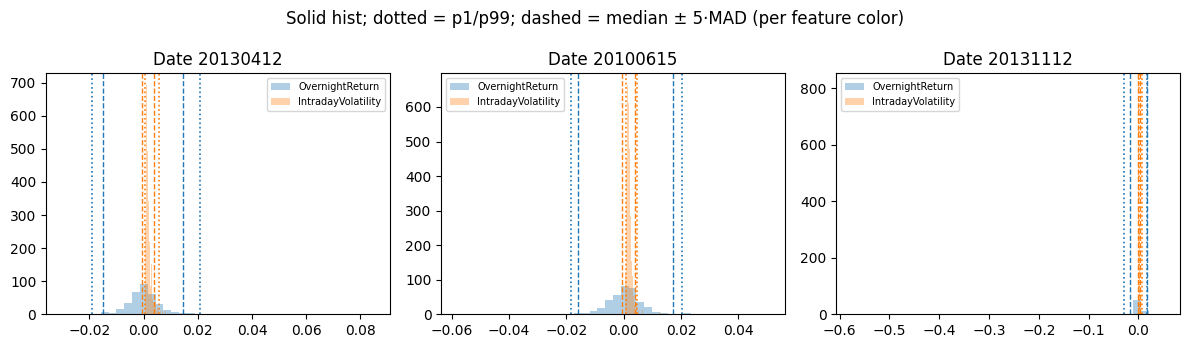

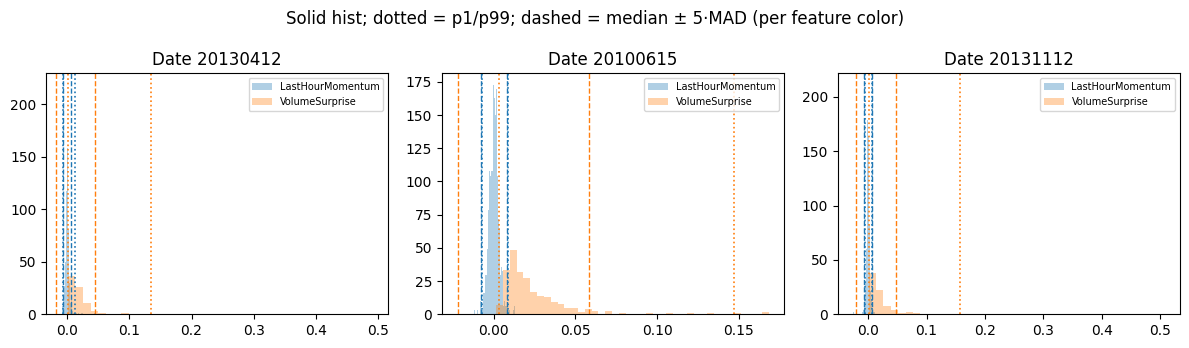

Features: winsorize → TS z per Id (window=252, min_periods=60) → CS z per date
Features built: ['OvernightReturn', 'FirstHourMomentum', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility', 'IntradayReturnSkew', 'RealizedDownsideVol', 'RealizedUpsideVol', 'VolumeSurprise', 'VolumeAfternoonMDV', 'VolumeMorningAfternoonRatio', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend', 'RetVolCorr']
Shape: (626431, 18)

After dropping rows with NaN: 546,246 rows
Train with features: 427,622 rows, 16 features
Validation with features: 117,241 rows


,Date,Id,OvernightReturn,FirstHourMomentum,LastHourMomentum,IntradayReversal,IntradayVolatility,IntradayReturnSkew,RealizedDownsideVol,RealizedUpsideVol,VolumeSurprise,VolumeAfternoonMDV,VolumeMorningAfternoonRatio,VolatilityAdjustedReturn,ShortTermReversal,Momentum21d,DollarVolTrend,RetVolCorr
40983,20100504,BBG000B9WH86,-0.405899,0.123525,-0.830455,0.440733,-0.395491,0.219766,-0.600266,-0.131479,0.405950,0.080750,0.084623,0.142671,-2.236128,-0.309044,-0.351818,0.030623
40984,20100504,BBG000B9WJ73,-0.473559,0.460917,1.124838,0.182527,-1.133020,-0.234640,-0.903424,-1.054204,-0.947114,-0.661454,-1.065427,-0.174482,-1.654194,1.118993,-1.245827,0.376799
40985,20100504,BBG000B9XRY4,0.826247,-0.175395,-0.331476,0.202185,0.954778,0.634476,0.503916,1.315083,-0.358742,-0.196437,-0.282815,0.386228,0.337022,0.536517,0.098856,-0.005872
40986,20100504,BBG000B9XYV2,-1.712579,3.133453,-1.687303,2.430700,3.135544,0.687817,1.604936,3.260436,0.159325,-0.236696,0.872485,1.443059,0.181016,-0.675644,-1.053688,2.448498
40988,20100504,BBG000B9ZXB4,-1.087885,-1.878738,1.197588,-2.026087,0.470380,-0.932043,1.219670,-0.801894,0.100845,-0.340719,1.484016,-1.752723,-1.549390,-0.111995,-0.546328,-1.311762
40989,20100504,BBG000BB07P9,1.999953,-1.184048,1.422369,-1.010054,1.023571,-0.179248,0.502630,0.987118,1.370681,0.406000,1.174333,2.490695,-2.042670,1.443866,2.288274,-0.788376
40990,20100504,BBG000BB1TH9,-1.492819,0.579286,-0.550960,0.116016,0.031543,0.658675,-0.486041,0.457137,-0.032895,-0.168871,0.192999,-0.577211,-0.088949,1.172571,0.831016,-0.230987
40991,20100504,BBG000BB29X4,-0.616310,0.036829,-1.524327,-0.048000,0.134650,0.327064,-0.393318,0.405350,0.507035,0.711953,-0.340545,0.385469,0.606761,1.402655,0.913016,-0.211306
40992,20100504,BBG000BB2DM7,0.862886,0.577486,1.733367,0.031118,0.263356,-0.127100,-0.049829,0.556322,1.781481,1.503299,-0.422753,1.454906,-1.766289,1.433532,1.613023,-0.523339
40993,20100504,BBG000BB2KW0,-1.495176,0.247150,0.599968,0.062563,0.741649,-0.365997,0.893183,0.369354,-0.388169,-0.818520,0.863133,-0.560554,0.202146,-1.437149,0.010302,0.680911


In [144]:
# Times we need (snapshots from 09:45 to 15:30 for volatility/correlation; specific times for others)
TIME_0945, TIME_1100, TIME_1200, TIME_1430, TIME_1530 = '09:45', '11:00', '12:00', '14:30', '15:30'

def load_day_pivoted(data_dir, date_str):
    """Load one day's intraday CSV; return wide DataFrames: CumReturnResid and CumVolume at each time (index=Id)."""
    path = Path(data_dir) / f'{date_str}.csv'
    if not path.exists():
        return None, None
    df = pd.read_csv(path)
    df['TimeStr'] = df['Time'].str[:5]  # e.g. 09:45:00.000 -> 09:45
    r = df.pivot_table(index='Id', columns='TimeStr', values='CumReturnResid', aggfunc='first')
    v = df.pivot_table(index='Id', columns='TimeStr', values='CumVolume', aggfunc='first')
    return r, v

def features_single_day(r, v, date_int):
    """Intraday features from CumReturnResid / CumVolume pivoted by time (15m grid 09:45–15:30)."""
    out = pd.DataFrame(index=r.index)
    out['Date'] = date_int
    out['Id'] = out.index
    # 1. Overnight return
    if TIME_0945 in r.columns:
        out['OvernightReturn'] = r[TIME_0945].values
    # Opening / first-hour momentum in residual space: 09:45 → 11:00, else 09:45 → 12:00
    if TIME_0945 in r.columns:
        if TIME_1100 in r.columns:
            out['FirstHourMomentum'] = (r[TIME_1100] - r[TIME_0945]).values
        elif TIME_1200 in r.columns:
            out['FirstHourMomentum'] = (r[TIME_1200] - r[TIME_0945]).values
    # 2. Last-hour momentum (14:30 -> 15:30)
    if TIME_1430 in r.columns and TIME_1530 in r.columns:
        out['LastHourMomentum'] = (r[TIME_1530] - r[TIME_1430]).values
    # CumReturnResid at 15:30 (for Volatility-Adjusted Return; daily EST_VOL from prev day)
    if TIME_1530 in r.columns:
        out['CumReturnResid_1530'] = r[TIME_1530].values
    # 3. Intraday reversal (morning - afternoon)
    if all(t in r.columns for t in [TIME_0945, TIME_1200, TIME_1530]):
        morning = r[TIME_1200] - r[TIME_0945]
        afternoon = r[TIME_1530] - r[TIME_1200]
        out['IntradayReversal'] = (morning - afternoon).values
    # 4–6. 15m increments 09:45→15:30: vol, skew, upside/downside realized vol, RetVolCorr
    times_ordered = [c for c in r.columns if c >= TIME_0945 and c <= TIME_1530]
    times_ordered = sorted(times_ordered, key=lambda t: (int(t[:2]), int(t[3:5])))
    ret_inc = None
    if len(times_ordered) >= 2:
        ret_inc = r[times_ordered].diff(axis=1).iloc[:, 1:]
        out['IntradayVolatility'] = ret_inc.std(axis=1).values
        out['IntradayReturnSkew'] = ret_inc.skew(axis=1).values
        arr = ret_inc.to_numpy(dtype=float)
        down_sq = np.where(arr < 0, arr * arr, np.nan)
        up_sq = np.where(arr > 0, arr * arr, np.nan)
        with np.errstate(all='ignore'):
            out['RealizedDownsideVol'] = np.sqrt(np.nanmean(down_sq, axis=1))
            out['RealizedUpsideVol'] = np.sqrt(np.nanmean(up_sq, axis=1))
    # Cumulative volumes for session-shape features (MDV scaling merged later)
    if v is not None:
        v_a = v.reindex(r.index)
        if TIME_0945 in v.columns:
            out['CumVolume_0945'] = v_a[TIME_0945].values
        if TIME_1200 in v.columns:
            out['CumVolume_1200'] = v_a[TIME_1200].values
        if TIME_1530 in v.columns:
            out['CumVolume_1530'] = v_a[TIME_1530].values
    # Return–volume correlation (corr of ret_inc vs vol_inc)
    if ret_inc is not None and v is not None:
        v_aligned = v.reindex(r.index)[times_ordered]
        vol_inc = v_aligned.diff(axis=1).iloc[:, 1:]
        out['RetVolCorr'] = ret_inc.corrwith(vol_inc, axis=1).values
    return out.reset_index(drop=True)

def winsorize_mad(df, col, n_mad=5):
    """Winsorize at ±n_mad * MAD cross-sectionally per date."""
    mad = df.groupby('Date')[col].transform(lambda x: np.median(np.abs(x - np.median(x))))
    mad = mad.replace(0, np.nan)
    med = df.groupby('Date')[col].transform('median')
    lo = med - n_mad * mad
    hi = med + n_mad * mad
    return df[col].clip(lower=lo.fillna(-np.inf), upper=hi.fillna(np.inf))

def winsorize_percentile(df, col, low=0.01, high=0.99):
    """Winsorize at [low, high] percentiles cross-sectionally per date."""
    lo = df.groupby('Date')[col].transform(lambda x: x.quantile(low))
    hi = df.groupby('Date')[col].transform(lambda x: x.quantile(high))
    return df[col].clip(lower=lo, upper=hi)

def zscore_cross_sectional(df, col):
    """Z-score within each date (cross-sectional). Use np.nan when std is 0."""
    return df.groupby('Date')[col].transform(lambda x: (x - x.mean()) / (x.std() or np.nan))


# Features: winsorize (CS) → TS z per Id → CS z (uses zscore_time_series_per_id from setup cell; TS_WINDOW / TS_MIN_PERIODS)

# Build features for all dates in dev_years (2010-2014)
dev_dates = [int(d) for d in date_strings if int(d) // 10_000 in dev_years]
feature_dfs = []
for date_str in date_strings:
    date_int = int(date_str)
    if date_int not in dev_dates:
        continue
    r, v = load_day_pivoted(data_dir, date_str)
    if r is None:
        continue
    one = features_single_day(r, v, date_int)
    feature_dfs.append(one)
feat_df = pd.concat(feature_dfs, ignore_index=True)

# Merge previous trading day's daily data (no look-ahead: at 15:30 we don't have same-day daily)
daily_prev_list = []
for D in feat_df['Date'].unique():
    D_prev = prev_date.get(D)
    if D_prev is None:
        continue
    d = daily_all[daily_all['Date'] == D_prev][['Id', 'EST_VOL', 'MDV_63']].copy()
    d = d.rename(columns={'EST_VOL': 'EST_VOL_prev', 'MDV_63': 'MDV_63_prev'})
    d['Date'] = D
    daily_prev_list.append(d)
daily_prev_merge = pd.concat(daily_prev_list, ignore_index=True)
feat_df = feat_df.merge(daily_prev_merge, on=['Date', 'Id'], how='left')

# Volume Surprise = CumVolume_1530 / MDV_63_prev (prev day); NaN if prev day MDV missing or zero
feat_df['VolumeSurprise'] = feat_df['CumVolume_1530'] / feat_df['MDV_63_prev'].replace(0, np.nan)
# Afternoon volume (12:00→15:30) vs 63d median dollar volume; morning vs afternoon cumulative increments
if 'CumVolume_1200' in feat_df.columns:
    feat_df['VolumeAfternoonMDV'] = (
        feat_df['CumVolume_1530'] - feat_df['CumVolume_1200']
    ) / feat_df['MDV_63_prev'].replace(0, np.nan)
if 'CumVolume_0945' in feat_df.columns and 'CumVolume_1200' in feat_df.columns:
    _vm = feat_df['CumVolume_1200'] - feat_df['CumVolume_0945']
    _va = feat_df['CumVolume_1530'] - feat_df['CumVolume_1200']
    feat_df['VolumeMorningAfternoonRatio'] = _vm / _va.replace(0, np.nan)
# Volatility-Adjusted Return = CumReturnResid_1530 / EST_VOL_prev (prev day)
feat_df['VolatilityAdjustedReturn'] = feat_df['CumReturnResid_1530'] / feat_df['EST_VOL_prev'].replace(0, np.nan)

# Daily-only features (all use past days only; no look-ahead)
# Short-term reversal: (Close*PxAdj)_{t-1} / (Close*PxAdj)_{t-2} - 1
# Momentum 21d: Close_adj_{t-2} / Close_adj_{t-23} - 1  (skip t-1 to avoid reversal)
# Dollar volume trend: mean(DollarVol, t-1..t-5) / MDV_63_{t-1}
daily_feat_list = []
for D in feat_df['Date'].unique():
    if D not in prev_date:
        continue
    D_prev = prev_date[D]
    D_prev2 = prev_date.get(D_prev)
    if D_prev2 is None:
        continue
    idx = date_list.index(D)
    if idx < 23:
        continue
    D_prev23 = date_list[idx - 23]  # 21 trading days before D_prev2 (D_prev2 is at idx-2)
    d1 = daily_all[daily_all['Date'] == D_prev][['Id', 'Close_adj', 'DollarVol', 'MDV_63']].rename(columns={'Close_adj': 'c1', 'DollarVol': 'dv1', 'MDV_63': 'MDV_63_1'})
    d2 = daily_all[daily_all['Date'] == D_prev2][['Id', 'Close_adj']].rename(columns={'Close_adj': 'c2'})
    d23 = daily_all[daily_all['Date'] == D_prev23][['Id', 'Close_adj']].rename(columns={'Close_adj': 'c23'})
    m = d1.merge(d2, on='Id', how='inner').merge(d23, on='Id', how='inner')
    m['ShortTermReversal'] = (m['c1'] / m['c2']) - 1
    m['Momentum21d'] = (m['c2'] / m['c23']) - 1
    # avg_dv_5d = mean(DollarVol) for t-1..t-5
    d_ = D_prev
    dv_list = []
    for _ in range(5):
        if d_ is None:
            break
        dv_list.append(daily_all[daily_all['Date'] == d_][['Id', 'DollarVol']])
        d_ = prev_date.get(d_)
    if len(dv_list) == 5:
        dv_5d = dv_list[0].rename(columns={'DollarVol': 'v0'})
        for i, df in enumerate(dv_list[1:], 1):
            dv_5d = dv_5d.merge(df.rename(columns={'DollarVol': f'v{i}'}), on='Id', how='outer')
        dv_5d['avg_dv_5d'] = dv_5d[['v0', 'v1', 'v2', 'v3', 'v4']].mean(axis=1)
        m = m.merge(dv_5d[['Id', 'avg_dv_5d']], on='Id', how='left')
        m['DollarVolTrend'] = m['avg_dv_5d'] / m['MDV_63_1'].replace(0, np.nan)
    else:
        m['DollarVolTrend'] = np.nan
    m = m[['Id', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend']].copy()
    m['Date'] = D
    daily_feat_list.append(m)
if daily_feat_list:
    daily_feat_df = pd.concat(daily_feat_list, ignore_index=True)
    feat_df = feat_df.merge(daily_feat_df, on=['Date', 'Id'], how='left')

# --- EDA: raw cross-sectional shapes & 5 MAD vs 1–99% (before winsorize) ---
RUN_FEATURE_DIST_EDA = True
USE_EDA_WINSOR_SUGGESTIONS = False  # True: winsor loop uses data-driven plan (requires RUN_FEATURE_DIST_EDA)
N_HIST_DATES = 3
RNG = np.random.default_rng(42)

# Manual plan (project spec). Overridden only when USE_EDA_WINSOR_SUGGESTIONS and EDA ran.
WINSOR_PLAN_DEFAULT = [
    ('OvernightReturn', True),
    ('FirstHourMomentum', True),
    ('LastHourMomentum', True),
    ('IntradayReversal', True),
    ('IntradayVolatility', False),
    ('IntradayReturnSkew', True),
    ('RealizedDownsideVol', False),
    ('RealizedUpsideVol', False),
    ('VolumeSurprise', False),
    ('VolumeAfternoonMDV', False),
    ('VolumeMorningAfternoonRatio', False),
    ('VolatilityAdjustedReturn', True),
    ('ShortTermReversal', True),
    ('Momentum21d', True),
    ('DollarVolTrend', True),
]

_raw_cols_for_winsor = [
    'OvernightReturn', 'FirstHourMomentum', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility',
    'IntradayReturnSkew', 'RealizedDownsideVol', 'RealizedUpsideVol',
    'VolumeSurprise', 'VolumeAfternoonMDV', 'VolumeMorningAfternoonRatio',
    'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend',
]


def _eda_stats_one_day(s, n_mad=5, min_n=30):
    """Cross-section on one date: shape, fraction outside ±n_mad·MAD, (p99−p1)/(2·n_mad·MAD)."""
    v = pd.to_numeric(s, errors='coerce').dropna().to_numpy()
    n = len(v)
    if n < min_n:
        return pd.Series({
            'count': n, 'skew': np.nan, 'excess_kurt': np.nan,
            'pct_clip_low': np.nan, 'pct_clip_high': np.nan, 'pct_clip_mad': np.nan,
            'mad': np.nan, 'width_pct_over_mad': np.nan,
        })
    med = float(np.median(v))
    mad = float(np.median(np.abs(v - med)))
    skew = float(pd.Series(v).skew())
    exk = float(pd.Series(v).kurtosis())  # Fisher (excess) kurtosis in pandas
    if not np.isfinite(mad) or mad == 0:
        return pd.Series({
            'count': n, 'skew': skew, 'excess_kurt': exk,
            'pct_clip_low': np.nan, 'pct_clip_high': np.nan, 'pct_clip_mad': np.nan,
            'mad': mad if np.isfinite(mad) else np.nan, 'width_pct_over_mad': np.nan,
        })
    lo, hi = med - n_mad * mad, med + n_mad * mad
    fl = float((v < lo).mean())
    fh = float((v > hi).mean())
    p1, p99 = np.percentile(v, [1, 99])
    w_mad = 2 * n_mad * mad
    return pd.Series({
        'count': n, 'skew': skew, 'excess_kurt': exk,
        'pct_clip_low': fl, 'pct_clip_high': fh, 'pct_clip_mad': fl + fh,
        'mad': mad, 'width_pct_over_mad': float((p99 - p1) / w_mad),
    })


def recommend_winsor_from_summary(
    summary,
    skew_thresh=0.75,
    asym_thresh=0.008,
    mad0_pct_thresh=5.0,
    mad_clip_median_thresh=0.12,
):
    """Heuristic 5 MAD vs 1–99% from per-feature EDA rows (one row per raw feature).

    Any triggered flag → suggest percentile winsor; otherwise 5 MAD.
    Thresholds are tunable; validate on your histograms before USE_EDA_WINSOR_SUGGESTIONS.
    """
    rows = []
    for feat, row in summary.iterrows():
        if feat == 'RetVolCorr':
            rows.append({
                'feature': feat, 'use_mad': np.nan, 'method': 'z-score only',
                'reasons': 'not winsorized in pipeline',
            })
            continue
        flags = []
        if row['pct_days_mad_zero'] >= mad0_pct_thresh:
            flags.append(f"MAD zero/degenerate on ≥{mad0_pct_thresh:g}% of days")
        if abs(row['median_skew']) >= skew_thresh:
            flags.append(f"|median day skew| ≥ {skew_thresh}")
        if row['median_asymmetry'] >= asym_thresh:
            flags.append(f"asymmetric MAD clipping (median |hi−lo clip %| ≥ {asym_thresh})")
        mc = row['median_pct_clip_5MAD']
        if np.isfinite(mc) and mc >= mad_clip_median_thresh:
            flags.append(f"median ±5 MAD clip rate {mc:.1%} ≥ {mad_clip_median_thresh:.0%} (percentile rule ≈2%)")
        use_mad = len(flags) == 0
        rows.append({
            'feature': feat,
            'use_mad': use_mad,
            'method': '5 MAD' if use_mad else '1–99%',
            'reasons': 'symmetric-ish; MAD stable; moderate MAD clip rate' if use_mad else '; '.join(flags),
        })
    return pd.DataFrame(rows)


if RUN_FEATURE_DIST_EDA:
    from IPython.display import display

    eda_rows = []
    for col in _raw_cols_for_winsor + (['RetVolCorr'] if 'RetVolCorr' in feat_df.columns else []):
        if col not in feat_df.columns:
            continue
        # Avoid groupby.apply shape quirks (single-group → Series, wrong columns).
        _day_rows = [_eda_stats_one_day(_ser) for _, _ser in feat_df.groupby('Date', sort=False)[col]]
        day_stats = pd.DataFrame(_day_rows)
        eda_rows.append({
            'feature': col,
            'days': len(day_stats),
            'median_n': day_stats['count'].median(),
            'median_skew': day_stats['skew'].median(),
            'median_excess_kurt': day_stats['excess_kurt'].median(),
            'median_pct_clip_5MAD': day_stats['pct_clip_mad'].median(),
            'median_asymmetry': (day_stats['pct_clip_high'] - day_stats['pct_clip_low']).abs().median(),
            'median_width_pct_over_mad': day_stats['width_pct_over_mad'].median(),
            'pct_days_mad_zero': (day_stats['mad'].isna() | (day_stats['mad'] == 0)).mean() * 100,
        })
    eda_summary = pd.DataFrame(eda_rows).set_index('feature')
    print('Per-day cross-section: median skew / excess kurtosis; median fraction clipped by ±5 MAD; '
          'median |upper−lower| clip asymmetry; median (p99−p1)/(10·MAD) (>1 → tighter MAD band than percentiles).')
    print('Percentile winsor always trims ≈2% in the cross-section (1% each tail) by construction.\n')
    display(eda_summary.round(4))

    winsor_suggest = recommend_winsor_from_summary(eda_summary)
    print('Heuristic winsor choice (tune thresholds inside recommend_winsor_from_summary):')
    display(winsor_suggest)

    # Histograms: a few liquid days, compare a return-like vs ratio-like feature
    n_per_date = feat_df.groupby('Date').size()
    good_dates = n_per_date[n_per_date >= 200].index.to_numpy()
    if len(good_dates) > 0:
        pick = RNG.choice(good_dates, size=min(N_HIST_DATES, len(good_dates)), replace=False)
        demo_pairs = [('OvernightReturn', 'IntradayVolatility'), ('LastHourMomentum', 'VolumeSurprise')]
        for a, b in demo_pairs:
            if a not in feat_df.columns or b not in feat_df.columns:
                continue
            fig, axes = plt.subplots(1, len(pick), figsize=(4 * len(pick), 3.5), sharey=False)
            if len(pick) == 1:
                axes = [axes]
            for ax, d in zip(axes, pick):
                for col, color in [(a, 'C0'), (b, 'C1')]:
                    s = feat_df.loc[feat_df['Date'] == d, col].dropna()
                    if len(s) < 30:
                        continue
                    med = np.median(s)
                    mad = np.median(np.abs(s - med))
                    p1, p99 = np.percentile(s, [1, 99])
                    ax.hist(s, bins=40, density=True, alpha=0.35, color=color, label=col)
                    if np.isfinite(mad) and mad > 0:
                        ax.axvline(med - 5 * mad, color=color, ls='--', lw=1)
                        ax.axvline(med + 5 * mad, color=color, ls='--', lw=1)
                    ax.axvline(p1, color=color, ls=':', lw=1.2)
                    ax.axvline(p99, color=color, ls=':', lw=1.2)
                ax.set_title(f'Date {d}')
                ax.legend(fontsize=7)
            fig.suptitle('Solid hist; dotted = p1/p99; dashed = median ± 5·MAD (per feature color)')
            plt.tight_layout()
            plt.show()

WINSOR_PLAN = list(WINSOR_PLAN_DEFAULT)
if USE_EDA_WINSOR_SUGGESTIONS:
    if not RUN_FEATURE_DIST_EDA:
        raise ValueError('USE_EDA_WINSOR_SUGGESTIONS requires RUN_FEATURE_DIST_EDA=True in the same run.')
    _m = winsor_suggest.dropna(subset=['use_mad']).set_index('feature')['use_mad'].astype(bool).to_dict()
    WINSOR_PLAN = [(c, _m[c]) for c, _ in WINSOR_PLAN_DEFAULT]
    print('Using EDA-driven WINSOR_PLAN:', WINSOR_PLAN)

# Normalize: ±5 MAD + z-score or [1,99]% + z-score per WINSOR_PLAN; z-score only for RetVolCorr
for col, use_mad in WINSOR_PLAN:
    if col not in feat_df.columns:
        continue
    if use_mad:
        feat_df[f'{col}_w'] = winsorize_mad(feat_df, col, n_mad=5)
    else:
        feat_df[f'{col}_w'] = winsorize_percentile(feat_df, col, 0.01, 0.99)
    wcol = f'{col}_w'
    feat_df[f'{col}_ts'] = zscore_time_series_per_id(feat_df, wcol)
    feat_df[f'{col}_norm'] = zscore_cross_sectional(feat_df, f'{col}_ts')
if 'RetVolCorr' in feat_df.columns:
    feat_df['RetVolCorr_ts'] = zscore_time_series_per_id(feat_df, 'RetVolCorr')
    feat_df['RetVolCorr_norm'] = zscore_cross_sectional(feat_df, 'RetVolCorr_ts')

feat_df = feat_df.drop(columns=[c for c in feat_df.columns if c.endswith('_ts')], errors='ignore')

# Keep only scaled feature columns and keys
norm_cols = [c for c in feat_df.columns if c.endswith('_norm')]
feat_df = feat_df[['Date', 'Id'] + norm_cols].copy()
feat_df.columns = ['Date', 'Id'] + [c.replace('_norm', '') for c in norm_cols]
feature_cols = [c for c in feat_df.columns if c not in ('Date', 'Id')]
print(f'Features: winsorize → TS z per Id (window={TS_WINDOW}, min_periods={TS_MIN_PERIODS}) → CS z per date')
print('Features built:', feature_cols)
print('Shape:', feat_df.shape)

feat_df = feat_df.dropna(subset=feature_cols)
print(f'\nAfter dropping rows with NaN: {len(feat_df):,} rows')

# Merge features to train/validation (inner join: only (Date,Id) present in both target and features)
# Keep only keys + non-feature columns from left to avoid duplicate columns when re-running this cell
left_cols = ['Date', 'Id'] + [c for c in train_df.columns if c not in feat_df.columns]
train_df = train_df[left_cols].merge(feat_df, on=['Date', 'Id'], how='inner')
val_df = val_df[left_cols].merge(feat_df, on=['Date', 'Id'], how='inner')
print(f'Train with features: {len(train_df):,} rows, {len(feature_cols)} features')
print(f'Validation with features: {len(val_df):,} rows')
feat_df.head(10)

## 5.1 Align with spec (target, normalization, weights)

- **Target:** **`Target_norm`** = per-`Id` time-series z of raw **Target** with past-only std floor + symmetric z-clip (setup: `TARGET_TSZ_STDFLOOR_REL`, `TARGET_TSZ_CLIP`); no CS winsor or CS z. **`Target_vol_scaled` = Target / EST_VOL_prev** for vol-scaled diagnostics only. Fit and predict in **`Target_norm`** space.
- **Features:** Winsorize → TS z per `Id` → CS z per date (same window params as target).
- **Weights:** Use `sqrt(MDV_63)` as sample weights when fitting. *Why MDV_63:* more liquid names (higher median daily volume) have more stable return estimates; √MDV_63 upweights them while muting a few very high-MDV names dominating the fit (spec: use sqrt or log).
- **Validation:** 2014 = validation set; 2010–2013 = training set; hold-out test TBA.

In [145]:
# Build (Date, Id, EST_VOL_prev, MDV_63_prev) for all dates that have a previous trading day
daily_prev_list = []
for D in pd.concat([train_df[['Date']], val_df[['Date']]], ignore_index=True)['Date'].unique():
    D_prev = prev_date.get(D)
    if D_prev is None:
        continue
    d = daily_all[daily_all['Date'] == D_prev][['Id', 'EST_VOL', 'MDV_63']].copy()
    d = d.rename(columns={'EST_VOL': 'EST_VOL_prev', 'MDV_63': 'MDV_63_prev'})
    d['Date'] = D
    daily_prev_list.append(d)
daily_prev = pd.concat(daily_prev_list, ignore_index=True)

# Merge EST_VOL_prev and MDV_63_prev into train and val (for normalization and sample weights)
train_df = train_df.merge(daily_prev[['Date', 'Id', 'EST_VOL_prev', 'MDV_63_prev']], on=['Date', 'Id'], how='left')
val_df = val_df.merge(daily_prev[['Date', 'Id', 'EST_VOL_prev', 'MDV_63_prev']], on=['Date', 'Id'], how='left')

# Drop rows where EST_VOL_prev is missing or 0 (needed for Target_vol_scaled diagnostics / scaling preds)
train_df = train_df[train_df['EST_VOL_prev'].notna() & (train_df['EST_VOL_prev'] > 0)].copy()
val_df = val_df[val_df['EST_VOL_prev'].notna() & (val_df['EST_VOL_prev'] > 0)].copy()

# Target_norm = per-Id TS z (from target build). Vol-scaled raw return for diagnostics only (no CS on target).
train_df['Target_vol_scaled'] = train_df['Target'] / train_df['EST_VOL_prev']
val_df['Target_vol_scaled'] = val_df['Target'] / val_df['EST_VOL_prev']

# Sample weights: sqrt(MDV_63) to mute effect of a few IDs dominating the fit
train_df['sample_weight'] = np.sqrt(train_df['MDV_63_prev'].replace(0, np.nan))
val_df['sample_weight'] = np.sqrt(val_df['MDV_63_prev'].replace(0, np.nan))

# Target_norm NaN rate (per-Id rolling z needs TS_MIN_PERIODS past rows; NaNs until history builds)
def _pct_nan_target_norm(label, d):
    s = d['Target_norm']
    n = len(s)
    k = int(s.isna().sum())
    pct = 100.0 * k / n if n else float('nan')
    print(f'{label} Target_norm: {k:,} NaN / {n:,} rows ({pct:.2f}%) — before dropna on Target_norm')

_pct_nan_target_norm('Train', train_df)
_pct_nan_target_norm('Validation', val_df)

train_df = train_df.dropna(subset=['sample_weight', 'Target_norm'])
val_df = val_df.dropna(subset=['sample_weight', 'Target_norm'])
print(f'After dropna: validation Target_norm NaN = {val_df["Target_norm"].isna().sum()} ({100 * val_df["Target_norm"].isna().mean():.4f}%).')

print('Align with spec:')
print(f'  Target for fitting: Target_norm = per-Id time-series z of raw Target (no CS winsor, no CS z).')
print(f'  Target_vol_scaled = Target / EST_VOL_prev (vol-scaled return proxy; not the fitted label).')
print(f'  Sample weights: sqrt(MDV_63_prev) applied per row.')
print(f'  Train: {len(train_df):,} rows (years {train_years}); Val: {len(val_df):,} rows (year {val_year}).')
print(f'  Hold-out test year will be provided later; do not refit after it is received.')
train_df[['Date', 'Id', 'Target', 'EST_VOL_prev', 'Target_vol_scaled', 'Target_norm', 'sample_weight']].head()

Train Target_norm: 0 NaN / 427,622 rows (0.00%) — before dropna on Target_norm
Validation Target_norm: 0 NaN / 117,241 rows (0.00%) — before dropna on Target_norm
After dropna: validation Target_norm NaN = 0 (0.0000%).
Align with spec:
  Target for fitting: Target_norm = per-Id time-series z of raw Target (no CS winsor, no CS z).
  Target_vol_scaled = Target / EST_VOL_prev (vol-scaled return proxy; not the fitted label).
  Sample weights: sqrt(MDV_63_prev) applied per row.
  Train: 427,622 rows (years [2010, 2011, 2012, 2013]); Val: 117,241 rows (year 2014).
  Hold-out test year will be provided later; do not refit after it is received.


,Date,Id,Target,EST_VOL_prev,Target_vol_scaled,Target_norm,sample_weight
0,20100504,BBG000B9WH86,-0.011410,0.24264,-0.047024,-0.523632,21115.664801
1,20100504,BBG000B9WJ73,0.003378,0.31310,0.010790,0.145584,11995.909303
2,20100504,BBG000B9XRY4,-0.008349,0.18740,-0.044552,-1.073963,65824.828143
3,20100504,BBG000B9XYV2,0.002127,0.20045,0.010609,0.358460,11888.335880
4,20100504,BBG000B9ZXB4,-0.004691,0.12694,-0.036957,-0.474274,20028.225084


## 6. Feature testing, cleaning, and normalization

**Summary for white paper:**
- **Testing:** Features are evaluated via train/validation split (2010–2013 train, 2014 val); model weighted R² on validation is the main metric. No formal univariate screening; all engineered features are kept and used in the models.
- **Cleaning:** Rows with any missing value in the feature set are dropped (`dropna(subset=feature_cols)`). Rows without valid `EST_VOL_prev` or `MDV_63_prev` (for weights and `Target_vol_scaled`) are dropped. **Target:** no CS winsor or CS z — **`Target_norm`** is per-`Id` TS z with past-only std floor + z-clip (see setup).
- **Normalization:** (1) **Features:** Cross-sectional winsorize, then TS z per `Id`, then CS z per date. (2) **Target:** **`Target_norm`** = TS z of raw return per `Id` with std floor + clip; **`Target_vol_scaled`** = Target / EST_VOL_prev for reference (not CS-transformed).

In [146]:
# Quick reference: feature list and normalization (matches Section 5 feature build)
mad_features = [
    'OvernightReturn', 'FirstHourMomentum', 'LastHourMomentum', 'IntradayReversal',
    'IntradayReturnSkew', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend',
]
pct_features = [
    'IntradayVolatility', 'RealizedDownsideVol', 'RealizedUpsideVol',
    'VolumeSurprise', 'VolumeAfternoonMDV', 'VolumeMorningAfternoonRatio',
]


def _feat_base_name(f):
    return f[:-5] if f.endswith('_hist') else f


def _scaling_desc(_f):
    return f'TS z (own past, w={TS_WINDOW}) → CS z'


feat_normalization = pd.DataFrame({
    'Feature': feature_cols,
    'Winsorization': [
        '±5 MAD' if _feat_base_name(f) in mad_features else ('1st–99th pct' if _feat_base_name(f) in pct_features else 'None')
        for f in feature_cols
    ],
    'Scaling': [_scaling_desc(f) for f in feature_cols],
})
print('Feature cleaning/normalization applied:')
display(feat_normalization)

Feature cleaning/normalization applied:


,Feature,Winsorization,Scaling
0,OvernightReturn,±5 MAD,"TS z (own past, w=252) → CS z"
1,FirstHourMomentum,±5 MAD,"TS z (own past, w=252) → CS z"
2,LastHourMomentum,±5 MAD,"TS z (own past, w=252) → CS z"
3,IntradayReversal,±5 MAD,"TS z (own past, w=252) → CS z"
4,IntradayVolatility,1st–99th pct,"TS z (own past, w=252) → CS z"
5,IntradayReturnSkew,±5 MAD,"TS z (own past, w=252) → CS z"
6,RealizedDownsideVol,1st–99th pct,"TS z (own past, w=252) → CS z"
7,RealizedUpsideVol,1st–99th pct,"TS z (own past, w=252) → CS z"
8,VolumeSurprise,1st–99th pct,"TS z (own past, w=252) → CS z"
9,VolumeAfternoonMDV,1st–99th pct,"TS z (own past, w=252) → CS z"


In [147]:
# Feature categories and full list (for white paper)
intraday_features = [
    'OvernightReturn', 'FirstHourMomentum', 'LastHourMomentum', 'IntradayReversal',
    'IntradayVolatility', 'IntradayReturnSkew', 'RealizedDownsideVol', 'RealizedUpsideVol',
    'VolumeSurprise', 'VolumeAfternoonMDV', 'VolumeMorningAfternoonRatio', 'RetVolCorr',
]
daily_features = ['VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend']


def _category_base(f):
    return f[:-5] if f.endswith('_hist') else f


feature_categories = pd.DataFrame({
    'Feature': feature_cols,
    'Category': ['Intraday' if _category_base(f) in intraday_features else 'Daily' for f in feature_cols],
})
print('Feature categories and full list (for white paper):')
display(feature_categories)

Feature categories and full list (for white paper):


,Feature,Category
0,OvernightReturn,Intraday
1,FirstHourMomentum,Intraday
2,LastHourMomentum,Intraday
3,IntradayReversal,Intraday
4,IntradayVolatility,Intraday
5,IntradayReturnSkew,Intraday
6,RealizedDownsideVol,Intraday
7,RealizedUpsideVol,Intraday
8,VolumeSurprise,Intraday
9,VolumeAfternoonMDV,Intraday


## 7. Models: Ridge, Random Forest, XGBoost (+ optional)

Required: **Ridge**, **Random Forest Regressor**, **XGBoost**. Fit on `Target_norm` with `sample_weight = sqrt(MDV_63)`. Tune hyperparameters on train/validation; report weighted R² on validation (weights = sqrt(MDV_63)).

In [148]:
from sklearn.linear_model import Ridge, ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score
from sklearn.model_selection import GridSearchCV, PredefinedSplit
from sklearn.preprocessing import StandardScaler
import warnings

# XGBoost (install if needed: pip install xgboost)
try:
    import xgboost as xgb
    HAS_XGB = True
except ImportError:
    HAS_XGB = False
    warnings.warn('XGBoost not installed; skip XGB model. pip install xgboost')

def weighted_r2(y_true, y_pred, sample_weight):
    """Weighted R² as per spec: use sqrt(MDV_63) for evaluation."""
    return r2_score(y_true, y_pred, sample_weight=sample_weight)

# Require non-empty train and validation before building matrices
if len(train_df) == 0 or len(val_df) == 0:
    raise ValueError(
        'Train or validation is empty. '
        'Train needs data for 2010–2013, validation for 2014. '
        'Ensure intraday and daily data (and target) include those years, then re-run from the split cell.'
    )

# Feature matrix and target (normalized for fitting)
X_train = train_df[feature_cols].astype(float)
y_train = train_df['Target_norm'].values
w_train = train_df['sample_weight'].values

X_val = val_df[feature_cols].astype(float)
y_val = val_df['Target_norm'].values
w_val = val_df['sample_weight'].values

# Standardize features: same scale everywhere so L1/L2 don't over-shrink rare-but-real channels
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)

print(f'Train: X {X_train.shape}, y {y_train.shape}, weights {w_train.shape}')
print(f'Val:   X {X_val.shape}, y {y_val.shape}, weights {w_val.shape}')
print(f'Features: {feature_cols}')

Train: X (427622, 16), y (427622,), weights (427622,)
Val:   X (117241, 16), y (117241,), weights (117241,)
Features: ['OvernightReturn', 'FirstHourMomentum', 'LastHourMomentum', 'IntradayReversal', 'IntradayVolatility', 'IntradayReturnSkew', 'RealizedDownsideVol', 'RealizedUpsideVol', 'VolumeSurprise', 'VolumeAfternoonMDV', 'VolumeMorningAfternoonRatio', 'VolatilityAdjustedReturn', 'ShortTermReversal', 'Momentum21d', 'DollarVolTrend', 'RetVolCorr']


In [149]:
# --- 1. Ridge Regression (required) ---
alphas = np.logspace(-3, 3, 25)  # 0.001 to 1000
ridge_scores = []
for alpha in alphas:
    m = Ridge(alpha=alpha, random_state=42)
    m.fit(X_train, y_train, sample_weight=w_train)
    pred_val = m.predict(X_val)
    r2 = weighted_r2(y_val, pred_val, w_val)
    ridge_scores.append((alpha, r2))
ridge_results = pd.DataFrame(ridge_scores, columns=['alpha', 'val_weighted_r2'])
best_alpha = ridge_results.loc[ridge_results['val_weighted_r2'].idxmax(), 'alpha']
ridge_best = Ridge(alpha=best_alpha, random_state=42)
ridge_best.fit(X_train, y_train, sample_weight=w_train)
ridge_val_r2 = weighted_r2(y_val, ridge_best.predict(X_val), w_val)
print('Ridge: best alpha =', best_alpha)
print('Ridge validation weighted R² =', round(ridge_val_r2, 6))

# Coefficient table: check size/sign (especially RealizedDownsideVol)
ridge_coef = pd.DataFrame({'Feature': feature_cols, 'coef': ridge_best.coef_})
ridge_coef['|coef|'] = ridge_coef['coef'].abs()
ridge_coef = ridge_coef.sort_values('|coef|', ascending=False)
ridge_coef['highlight'] = ridge_coef['Feature'].apply(lambda f: ' ←' if f == 'RealizedDownsideVol' else '')
print('\nRidge coefficients (|coef| desc):')
display(ridge_coef[['Feature', 'coef', '|coef|', 'highlight']])

ridge_results.head(10)

Ridge: best alpha = 1000.0
Ridge validation weighted R² = 0.000481

Ridge coefficients (|coef| desc):


,Feature,coef,|coef|,highlight
6,RealizedDownsideVol,0.033774,0.033774,←
4,IntradayVolatility,-0.025675,0.025675,
0,OvernightReturn,0.013395,0.013395,
8,VolumeSurprise,0.011769,0.011769,
2,LastHourMomentum,-0.011719,0.011719,
5,IntradayReturnSkew,0.011370,0.011370,
11,VolatilityAdjustedReturn,-0.009358,0.009358,
12,ShortTermReversal,-0.008606,0.008606,
15,RetVolCorr,0.006714,0.006714,
7,RealizedUpsideVol,-0.006535,0.006535,


,alpha,val_weighted_r2
0,0.001000,0.000481
1,0.001778,0.000481
2,0.003162,0.000481
3,0.005623,0.000481
4,0.010000,0.000481
5,0.017783,0.000481
6,0.031623,0.000481
7,0.056234,0.000481
8,0.100000,0.000481
9,0.177828,0.000481


In [162]:
# --- 2. Random Forest Regressor (required) ---
# Speed: cap bootstrap size per tree (full ~400k+ rows is very slow); tune on fewer trees then refit once
_n_rf = X_train.shape[0]
_rf_max_samples = min(80_000, _n_rf)  # each tree sees at most this many rows (with replacement)
max_depths = [5, 8]
n_est_tune = 35
min_leaf = [10, 20]
rf_scores = []
for md in max_depths:
    for ml in min_leaf:
        m = RandomForestRegressor(
            n_estimators=n_est_tune, max_depth=md, min_samples_leaf=ml,
            max_samples=_rf_max_samples, random_state=42, n_jobs=-1,
        )
        m.fit(X_train, y_train, sample_weight=w_train)
        r2 = weighted_r2(y_val, m.predict(X_val), w_val)
        rf_scores.append({'max_depth': md, 'min_samples_leaf': ml, 'val_weighted_r2': r2})
rf_results = pd.DataFrame(rf_scores)
best_rf = rf_results.loc[rf_results['val_weighted_r2'].idxmax()]
n_est_final = 80
rf_best = RandomForestRegressor(
    n_estimators=n_est_final, max_depth=int(best_rf['max_depth']),
    min_samples_leaf=int(best_rf['min_samples_leaf']),
    max_samples=_rf_max_samples, random_state=42, n_jobs=-1,
)
rf_best.fit(X_train, y_train, sample_weight=w_train)
rf_val_r2 = weighted_r2(y_val, rf_best.predict(X_val), w_val)
print(
    'Random Forest: best params =', best_rf[['max_depth', 'min_samples_leaf']].to_dict(),
    f'(n_estimators={n_est_final}, max_samples={_rf_max_samples} per tree)',
)
print('Random Forest validation weighted R² =', round(rf_val_r2, 6))
rf_results.sort_values('val_weighted_r2', ascending=False)

Random Forest: best params = {'max_depth': 5.0, 'min_samples_leaf': 20.0} (n_estimators=80, max_samples=80000 per tree)
Random Forest validation weighted R² = -0.001035


,max_depth,min_samples_leaf,val_weighted_r2
1,5,20,-0.001243
3,8,20,-0.001694
0,5,10,-0.003833
2,8,10,-0.004332


In [151]:
# --- 3. XGBoost Regressor (required) ---
if HAS_XGB:
    xgb_params = []
    for md in [3, 4, 5, 6]:
        for lr in [0.03, 0.05, 0.1]:
            for ne in [100, 200]:
                m = xgb.XGBRegressor(n_estimators=ne, max_depth=md, learning_rate=lr, random_state=42, n_jobs=-1)
                m.fit(X_train, y_train, sample_weight=w_train)
                r2 = weighted_r2(y_val, m.predict(X_val), w_val)
                xgb_params.append({'max_depth': md, 'learning_rate': lr, 'n_estimators': ne, 'val_weighted_r2': r2})
    xgb_results = pd.DataFrame(xgb_params)
    best_xgb = xgb_results.loc[xgb_results['val_weighted_r2'].idxmax()]
    xgb_best = xgb.XGBRegressor(
        n_estimators=int(best_xgb['n_estimators']), max_depth=int(best_xgb['max_depth']),
        learning_rate=best_xgb['learning_rate'], random_state=42, n_jobs=-1
    )
    xgb_best.fit(X_train, y_train, sample_weight=w_train)
    xgb_val_r2 = weighted_r2(y_val, xgb_best.predict(X_val), w_val)
    print('XGBoost: best params =', best_xgb[['max_depth', 'learning_rate', 'n_estimators']].to_dict())
    print('XGBoost validation weighted R² =', round(xgb_val_r2, 6))
    xgb_results.sort_values('val_weighted_r2', ascending=False).head(10)
else:
    xgb_best = None
    xgb_val_r2 = np.nan

XGBoost: best params = {'max_depth': 3.0, 'learning_rate': 0.03, 'n_estimators': 100.0}
XGBoost validation weighted R² = -0.003675


In [163]:
# --- 4. Optional: ElasticNet (L1 + L2) ---
# Speed: tune on a random train subset + coarser grid; refit best on full train. Val scoring unchanged.
# Set EN_TUNE_MAX_ROWS = None to tune on full train (slow).
EN_TUNE_MAX_ROWS = 100_000
rng_en = np.random.default_rng(42)
_n_tr_en = len(X_train)
if EN_TUNE_MAX_ROWS is not None and _n_tr_en > EN_TUNE_MAX_ROWS:
    _idx_en = rng_en.choice(_n_tr_en, size=EN_TUNE_MAX_ROWS, replace=False)
    X_en_tune, y_en_tune, w_en_tune = X_train[_idx_en], y_train[_idx_en], w_train[_idx_en]
    print(f'ElasticNet grid: tuning on {_idx_en.size} / {_n_tr_en} train rows')
else:
    X_en_tune, y_en_tune, w_en_tune = X_train, y_train, w_train

alphas_en = np.logspace(-5, -0.5, 12)
l1_ratios = [0.8, 0.9, 0.95, 1.0]
en_scores = []
for alpha in alphas_en:
    for l1 in l1_ratios:
        m = ElasticNet(alpha=alpha, l1_ratio=l1, random_state=42)
        m.fit(X_en_tune, y_en_tune, sample_weight=w_en_tune)
        r2 = weighted_r2(y_val, m.predict(X_val), w_val)
        en_scores.append({'alpha': alpha, 'l1_ratio': l1, 'val_weighted_r2': r2})
en_results = pd.DataFrame(en_scores)
best_en = en_results.loc[en_results['val_weighted_r2'].idxmax()]
en_best = ElasticNet(alpha=best_en['alpha'], l1_ratio=best_en['l1_ratio'], random_state=42)
en_best.fit(X_train, y_train, sample_weight=w_train)
en_val_r2 = weighted_r2(y_val, en_best.predict(X_val), w_val)
print('ElasticNet: best alpha =', best_en['alpha'], ', l1_ratio =', best_en['l1_ratio'])
print('ElasticNet validation weighted R² =', round(en_val_r2, 6))

# Coefficient table: check size/sign; RealizedDownsideVol dominance vs over-shrink of rare channels
en_coef = pd.DataFrame({'Feature': feature_cols, 'coef': en_best.coef_})
en_coef['|coef|'] = en_coef['coef'].abs()
en_coef = en_coef.sort_values('|coef|', ascending=False)
en_coef['highlight'] = en_coef['Feature'].apply(lambda f: ' ←' if f == 'RealizedDownsideVol' else '')
print('\nElasticNet coefficients (|coef| desc):')
display(en_coef[['Feature', 'coef', '|coef|', 'highlight']])

ElasticNet grid: tuning on 100000 / 427622 train rows
ElasticNet: best alpha = 1e-05 , l1_ratio = 0.8
ElasticNet validation weighted R² = 0.000482

ElasticNet coefficients (|coef| desc):


,Feature,coef,|coef|,highlight
6,RealizedDownsideVol,0.033506,0.033506,←
4,IntradayVolatility,-0.025308,0.025308,
0,OvernightReturn,0.013376,0.013376,
8,VolumeSurprise,0.011726,0.011726,
2,LastHourMomentum,-0.011719,0.011719,
5,IntradayReturnSkew,0.011321,0.011321,
11,VolatilityAdjustedReturn,-0.009340,0.009340,
12,ShortTermReversal,-0.008598,0.008598,
15,RetVolCorr,0.006701,0.006701,
7,RealizedUpsideVol,-0.006684,0.006684,


In [153]:
# --- Summary: compare all models (validation weighted R²) ---
summary = [
    ('Ridge', ridge_val_r2, ridge_best),
    ('Random Forest', rf_val_r2, rf_best),
    ('XGBoost', xgb_val_r2 if HAS_XGB else np.nan, xgb_best),
    ('ElasticNet', en_val_r2, en_best),
]
summary_df = pd.DataFrame([(n, r2) for n, r2, _ in summary], columns=['Model', 'Val_weighted_R2'])
print(summary_df.to_string(index=False))
best_name = summary_df.loc[summary_df['Val_weighted_R2'].idxmax(), 'Model']
print(f'\nBest on validation (weighted R²): {best_name}')
models_fitted = {name: model for name, _, model in summary if model is not None}
best_model = models_fitted[best_name]

# OOS R² with actuals clipped at 5 MAD cross-sectionally (per spec)
# No cross-sectional clipping on target / actuals (per target spec)
oos_r2_val = weighted_r2(y_val, best_model.predict(X_val), w_val)
print(f'Validation weighted R² (no CS clip on target): {oos_r2_val:.6f}')
# Model predicts Target_norm (per-Id TS z of raw target). For vol-scaled returns compare to Target_vol_scaled; pred * EST_VOL is not the inverse of TS z.

        Model  Val_weighted_R2
        Ridge         0.000481
Random Forest        -0.008638
      XGBoost        -0.003675
   ElasticNet         0.000492

Best on validation (weighted R²): ElasticNet
Validation weighted R² (no CS clip on target): 0.000492


### 7.1 Feature importance (MDA / MDI)

- **MDA (Mean Decrease in Accuracy):** permutation importance — shuffle each feature column and measure drop in weighted R² on validation. Model-agnostic.
- **MDI (Mean Decrease in Impurity):** tree-based importance from Random Forest / XGBoost (`feature_importances_`). Shown for the best tree model when available.

Feature importance from best model: ElasticNet

MDA (permutation importance, validation set):


,Feature,MDA_importance,MDA_std
6,RealizedDownsideVol,9.296752e-04,0.000129
8,VolumeSurprise,3.068224e-04,0.000068
2,LastHourMomentum,2.850938e-04,0.000087
5,IntradayReturnSkew,2.606237e-04,0.000027
0,OvernightReturn,1.944699e-04,0.000096
7,RealizedUpsideVol,1.690181e-04,0.000074
15,RetVolCorr,1.248002e-04,0.000035
3,IntradayReversal,1.135883e-04,0.000032
4,IntradayVolatility,8.857867e-05,0.000059
10,VolumeMorningAfternoonRatio,6.775756e-05,0.000023



MDI not available (linear model).


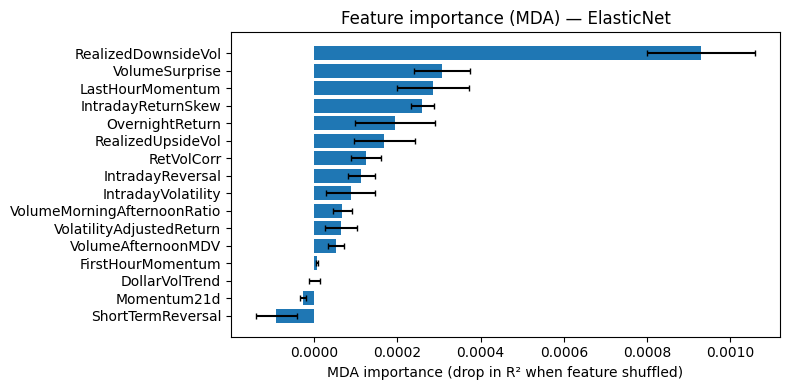

In [154]:
from sklearn.inspection import permutation_importance

# Use best model by validation R² for importance (or pick one, e.g. rf_best)
best_model_name = summary_df.loc[summary_df['Val_weighted_R2'].idxmax(), 'Model']
best_model = models_fitted[best_model_name]
print(f'Feature importance from best model: {best_model_name}\n')

# MDA: permutation importance on validation set (with sample weights)
perm = permutation_importance(
    best_model, X_val, y_val, n_repeats=8, random_state=42,
    sample_weight=w_val, scoring='r2', n_jobs=-1
)
imp_mda = pd.DataFrame({
    'Feature': feature_cols,
    'MDA_importance': perm.importances_mean,
    'MDA_std': perm.importances_std,
}).sort_values('MDA_importance', ascending=False)
print('MDA (permutation importance, validation set):')
display(imp_mda)

# MDI: tree-based importance (only for RF / XGBoost)
if hasattr(best_model, 'feature_importances_'):
    imp_mdi = pd.DataFrame({
        'Feature': feature_cols,
        'MDI_importance': best_model.feature_importances_,
    }).sort_values('MDI_importance', ascending=False)
    print('\nMDI (mean decrease impurity):')
    display(imp_mdi)
else:
    imp_mdi = imp_mda[['Feature']].copy()
    imp_mdi['MDI_importance'] = np.nan
    print('\nMDI not available (linear model).')

# Bar plot: MDA importance
fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(imp_mda['Feature'][::-1], imp_mda['MDA_importance'][::-1], xerr=imp_mda['MDA_std'][::-1], capsize=2)
ax.set_xlabel('MDA importance (drop in R² when feature shuffled)')
ax.set_title(f'Feature importance (MDA) — {best_model_name}')
plt.tight_layout()
plt.show()

### 7.2 Bin plots: most significant features vs target

For each of the top features (by MDA importance), we bin the feature into 4–5 bins and plot the mean target (and optionally mean prediction) in each bin to show the relationship with the target variable.

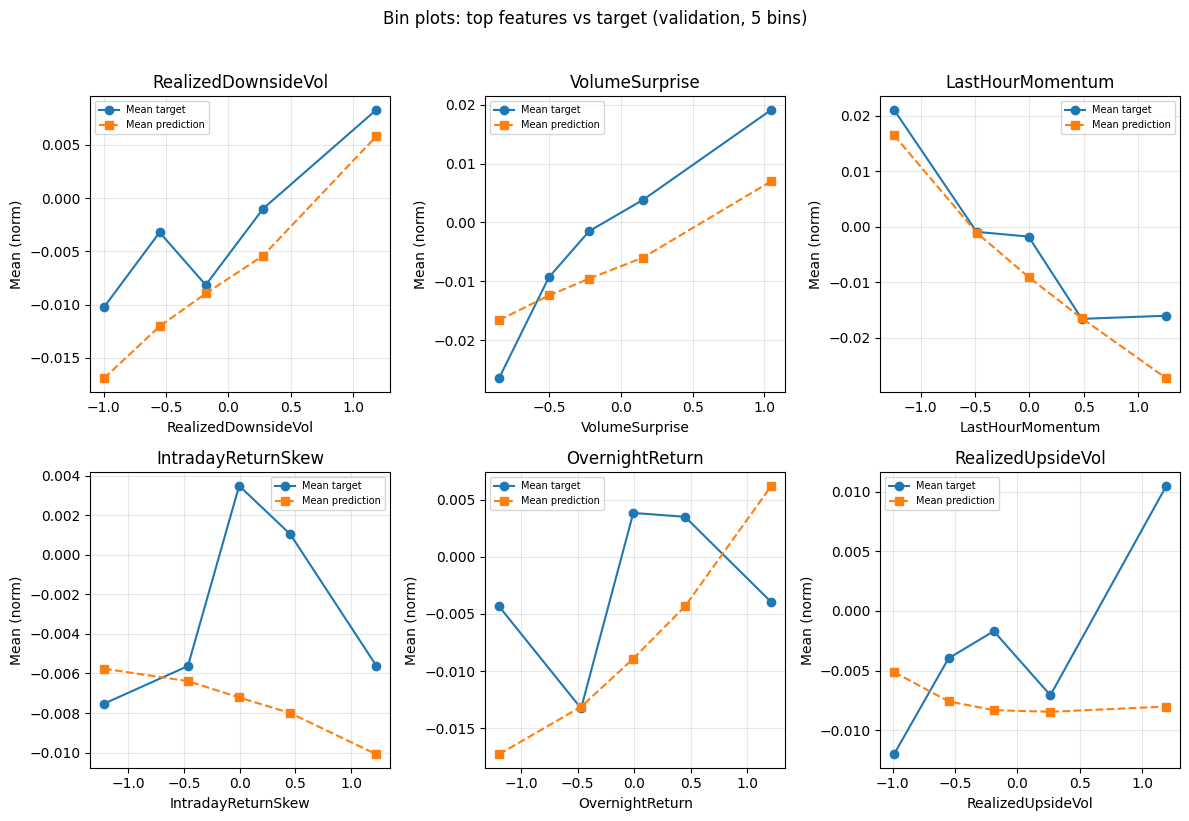

In [155]:
# Bin plots: top features vs target (validation set)
n_top = min(6, len(feature_cols))
top_features = imp_mda['Feature'].head(n_top).tolist()
n_bins = 5
val_plot = val_df[feature_cols + ['Target_norm']].copy()
val_plot['Pred_norm'] = best_model.predict(X_val)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()
for idx, feat in enumerate(top_features):
    ax = axes[idx]
    # Bin feature (quantile-based so each bin has similar count)
    val_plot['_bin'] = pd.qcut(val_plot[feat], q=n_bins, labels=False, duplicates='drop')
    binned = val_plot.groupby('_bin', observed=True).agg(
        mean_target=('Target_norm', 'mean'),
        mean_pred=('Pred_norm', 'mean'),
        mid_feat=(feat, 'median'),
    ).reset_index()
    x = binned['mid_feat'].values
    ax.plot(x, binned['mean_target'], 'o-', label='Mean target', color='C0')
    ax.plot(x, binned['mean_pred'], 's--', label='Mean prediction', color='C1')
    ax.set_xlabel(feat)
    ax.set_ylabel('Mean (norm)')
    ax.set_title(feat)
    ax.legend(loc='best', fontsize=7)
    ax.grid(True, alpha=0.3)
for j in range(len(top_features), len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Bin plots: top features vs target (validation, 5 bins)', y=1.02)
plt.tight_layout()
plt.show()

### Hold-out test: apply pre-trained model without refitting

Per spec: when the hold-out test year is provided, **do not refit**. Compute features and apply the saved model. Below: save best model and `feature_cols` so you can load and predict on new data.

### Performance on validation (2014) — for white paper

Per white paper requirements: final hyperparameters for each technique, R² weighted by 1/estVol, 30-day moving average of cross-sectional correlation (predictions vs target), and drift-style plot.

In [156]:
# Final hyperparameters for every technique (white paper table)
hp_ridge = {'alpha': best_alpha}
hp_rf = {'max_depth': int(best_rf['max_depth']), 'min_samples_leaf': int(best_rf['min_samples_leaf']), 'n_estimators': n_est_final}
hp_xgb = {'max_depth': int(best_xgb['max_depth']), 'learning_rate': best_xgb['learning_rate'], 'n_estimators': int(best_xgb['n_estimators'])} if HAS_XGB else {}
hp_en = {'alpha': best_en['alpha'], 'l1_ratio': best_en['l1_ratio']}
hyperparam_table = pd.DataFrame([
    ('Ridge', str(hp_ridge), ridge_val_r2),
    ('Random Forest', str(hp_rf), rf_val_r2),
    ('XGBoost', str(hp_xgb), xgb_val_r2 if HAS_XGB else np.nan),
    ('ElasticNet', str(hp_en), en_val_r2),
], columns=['Model', 'Final hyperparameters', 'Val weighted R² (√MDV_63)'])
print('Final hyperparameters and validation R² (for white paper):')
display(hyperparam_table)

Final hyperparameters and validation R² (for white paper):


,Model,Final hyperparameters,Val weighted R² (√MDV_63)
0,Ridge,{'alpha': 1000.0},0.000481
1,Random Forest,"{'max_depth': 8, 'min_samples_leaf': 20, 'n_es...",-0.008638
2,XGBoost,"{'max_depth': 3, 'learning_rate': 0.03, 'n_est...",-0.003675
3,ElasticNet,"{'alpha': 0.00045487779470037773, 'l1_ratio': ...",0.000492


#### White paper visualizations (export for appendix)

1. **Bin plot (validation 2014):** Predictions binned into 4; mean actual target per bin.  
2. **30-day MA correlation:** Cross-sectional correlation (pred vs target) and its 30-day moving average.  
3. **Drift plot:** Mean target by prediction bin over time (4 bins; ±1 SE bands).  
4. **Feature importance (MDA):** Bar chart of permutation importance (Section 7.1 below).

In [157]:
# R² weighted by 1/estVol (white paper: alternative weight)
w_estvol = 1.0 / val_df['EST_VOL_prev'].replace(0, np.nan)
w_estvol = w_estvol.fillna(w_estvol.median()).values  # avoid inf
r2_1estvol = r2_score(y_val, best_model.predict(X_val), sample_weight=w_estvol)
print(f'Validation R² weighted by 1/EST_VOL (white paper): {r2_1estvol:.6f}')
print(f'Validation R² weighted by √MDV_63 (benchmark):     {weighted_r2(y_val, best_model.predict(X_val), w_val):.6f}')

Validation R² weighted by 1/EST_VOL (white paper): 0.000476
Validation R² weighted by √MDV_63 (benchmark):     0.000492


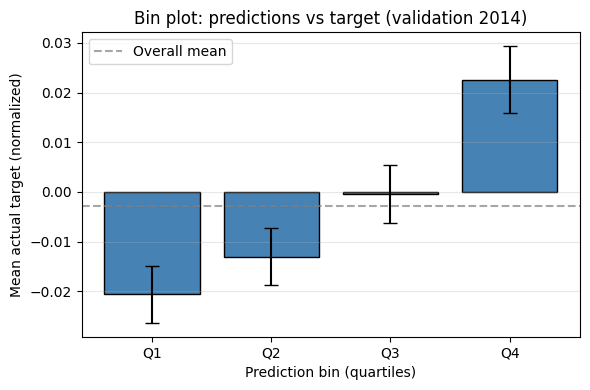

In [158]:
# Bin plot (white paper): 4 bins of predictions, mean actual target per bin — validation 2014
val_pred = val_df[['Date']].copy()
val_pred['Pred'] = best_model.predict(X_val)
val_pred['Target_norm'] = y_val
val_pred['Pred_bin'] = pd.qcut(val_pred['Pred'], q=4, labels=['Q1', 'Q2', 'Q3', 'Q4'], duplicates='drop')
bin_stats = val_pred.groupby('Pred_bin', observed=True)['Target_norm'].agg(['mean', 'std', 'count'])
bin_stats['se'] = bin_stats['std'] / np.sqrt(bin_stats['count'])
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(bin_stats))
ax.bar(x, bin_stats['mean'], yerr=bin_stats['se'], capsize=5, color='steelblue', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(bin_stats.index)
ax.set_xlabel('Prediction bin (quartiles)')
ax.set_ylabel('Mean actual target (normalized)')
ax.set_title('Bin plot: predictions vs target (validation 2014)')
ax.axhline(y_val.mean(), color='gray', linestyle='--', alpha=0.7, label='Overall mean')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

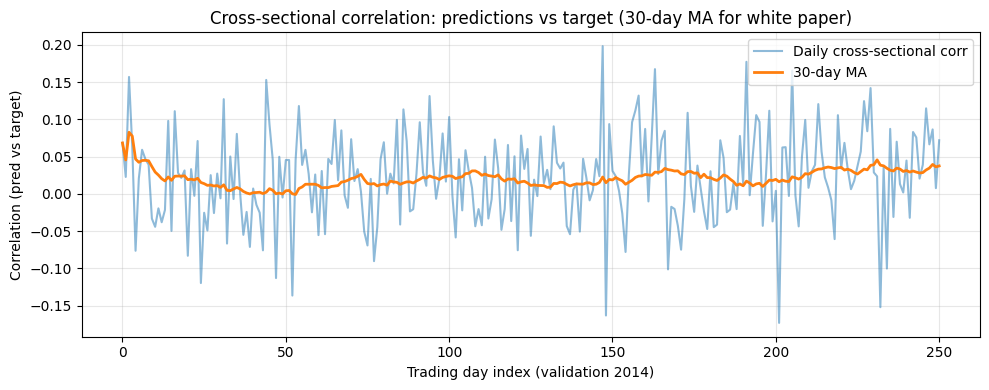

In [159]:
# 30-day moving average of cross-sectional correlation (predictions vs target) — white paper
val_pred = val_df[['Date']].copy()
val_pred['Pred'] = best_model.predict(X_val)
val_pred['Target_norm'] = y_val
daily_corr = val_pred.groupby('Date').apply(lambda g: g['Pred'].corr(g['Target_norm'])).reset_index()
daily_corr.columns = ['Date', 'corr']
daily_corr['corr_ma30'] = daily_corr['corr'].rolling(30, min_periods=1).mean()
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(range(len(daily_corr)), daily_corr['corr'], alpha=0.5, label='Daily cross-sectional corr')
ax.plot(range(len(daily_corr)), daily_corr['corr_ma30'], label='30-day MA', color='C1', lw=2)
ax.set_xlabel('Trading day index (validation 2014)')
ax.set_ylabel('Correlation (pred vs target)')
ax.set_title('Cross-sectional correlation: predictions vs target (30-day MA for white paper)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

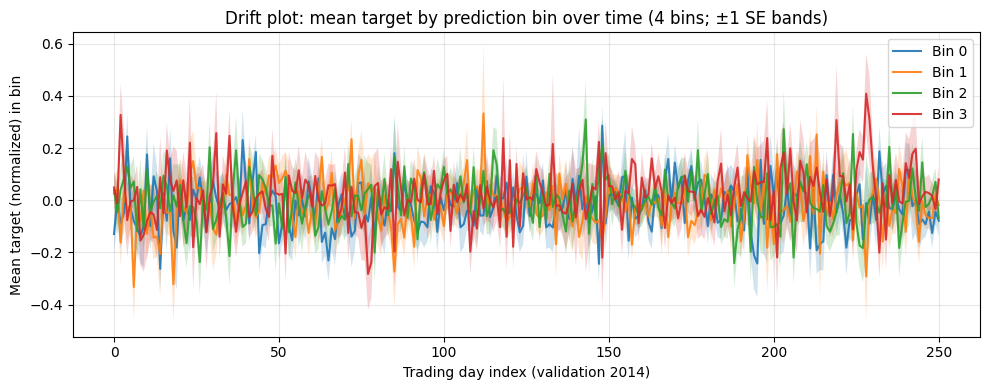

In [160]:
# Drift plot (white paper): 4 bins of predictions; mean target by bin over time with ±1 SE bands
# Full spec uses 15-min cumulative return paths from 24h before to 48h after; here we show mean target by bin per date.
val_drift = val_pred.copy()
val_drift['Bin'] = pd.qcut(val_drift['Pred'], q=4, labels=False, duplicates='drop')
drift_agg = val_drift.groupby(['Date', 'Bin'])['Target_norm'].agg(['mean', 'std', 'count']).reset_index()
drift_agg['se'] = drift_agg['std'] / np.sqrt(drift_agg['count'].clip(lower=1))
drift_by_date = drift_agg.pivot(index='Date', columns='Bin', values='mean')
se_by_date = drift_agg.pivot(index='Date', columns='Bin', values='se')
fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(len(drift_by_date))
for b in drift_by_date.columns:
    mean_vals = drift_by_date[b].values
    se_vals = se_by_date[b].values if b in se_by_date.columns else np.zeros_like(mean_vals)
    se_vals = np.nan_to_num(se_vals, nan=0.0)
    ax.plot(x, mean_vals, label=f'Bin {b}', alpha=0.9)
    ax.fill_between(x, mean_vals - se_vals, mean_vals + se_vals, alpha=0.2)
ax.set_xlabel('Trading day index (validation 2014)')
ax.set_ylabel('Mean target (normalized) in bin')
ax.set_title('Drift plot: mean target by prediction bin over time (4 bins; ±1 SE bands)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [161]:
import pickle
from pathlib import Path

# Save best model and metadata for hold-out test (no refit when new data arrives)
model_dir = Path('saved_model')
model_dir.mkdir(exist_ok=True)
with open(model_dir / 'best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
with open(model_dir / 'feature_cols.pkl', 'wb') as f:
    pickle.dump(feature_cols, f)
with open(model_dir / 'scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)
print(f'Saved {best_name} to {model_dir}/best_model.pkl, feature_cols.pkl, scaler.pkl')

# Example: load and predict on new data (no refit)
# with open(model_dir / 'best_model.pkl', 'rb') as f:
#     loaded_model = pickle.load(f)
# with open(model_dir / 'feature_cols.pkl', 'rb') as f:
#     loaded_feature_cols = pickle.load(f)
# with open(model_dir / 'scaler.pkl', 'rb') as f:
#     loaded_scaler = pickle.load(f)
# X_new = loaded_scaler.transform(new_df[loaded_feature_cols].astype(float))
# pred_norm = loaded_model.predict(X_new)
# pred_norm matches Target_norm (TS z per Id); not raw return — pred * EST_VOL alone is not the inverse

Saved ElasticNet to saved_model/best_model.pkl, feature_cols.pkl, scaler.pkl
